# 02: Decoding messages, and what the GNSS actually looks like

Notebook 01 listed topics without reading a single measurement. This one opens the messages.

**Questions to answer:**

1. How do the custom NavINST message types get decoded?
2. What fields does each of the four streams carry, and in what units?
3. Does `NavSatFix` publish a usable position covariance, or is it left as zeros? This decides which branch of `CLAUDE.md` §14's adaptive-$R$ table applies.
4. Where does GNSS quality actually degrade, and are there real outages? This decides what E3 can measure.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rosbags.highlevel import AnyReader

REPO = Path.cwd()
if not (REPO / "data").exists():
    REPO = REPO.parent
RAW = REPO / "data" / "raw"

SEQUENCES = {
    "Urban03": RAW / "Urban03" / "2023-11-03-09-42-41-Day",
    "Urban04": RAW / "Urban04" / "2023-11-01-12-16-16-Day",
    "Urban05": RAW / "Urban05" / "2024-06-04-21-14-50-Day",
}
PRIMARY = SEQUENCES["Urban04"]

TOPICS = {
    "imu": ("imus.bag", "/xsens/imu"),
    "gnss": ("gnss.bag", "/xsens/gnss"),
    "speed": ("imus.bag", "/obd2/speed"),
    "truth": ("reference.bag", "/novatel/reference/postprocessed/inspva"),
}

## How decoding works, and why no registration is needed

A bag stores messages as **packed bytes**. To turn those bytes into fields you need the schema, the `.msg` definition. For standard types such as `sensor_msgs/msg/Imu` the library already knows the schema. For NavINST's custom types (`INSPVA`, `ObdMeasurmentStamped`) it does not.

The documented route is to install the `navinst_ros` package into a catkin workspace and build it, which needs ROS Noetic on Ubuntu. That is not available here.

**It turns out not to be necessary.** A ROS1 bag embeds the *full text* of every message definition in its connection records, in `connection.msgdef`. The bag describes itself. `AnyReader` reads those definitions when it opens the file and registers the types automatically, so `reader.deserialize(raw, conn.msgtype)` simply works for custom types.

This also sidesteps a trap: the OBD type is declared in the bag as `navinst_obd_driver/msg/ObdMeasurmentStamped`, while the cloned repository keeps the definition under `navinst_ros/msg/`. Registering it manually by the repository's package name would fail to resolve. Taking the definition from the bag means the names always match.

The cell below proves it on both a standard and a custom type.

In [2]:
def first_message(sequence: Path, bag: str, topic: str):
    """Return (bag_timestamp_ns, decoded_message) for the first message on a topic."""
    with AnyReader([sequence / bag]) as reader:
        conns = [c for c in reader.connections if c.topic == topic]
        if not conns:
            raise KeyError(f"{topic} not found in {bag}")
        for conn, timestamp, raw in reader.messages(connections=conns):
            return timestamp, reader.deserialize(raw, conn.msgtype)


def fields(msg) -> list[str]:
    """Public field names of a decoded message."""
    return [f for f in dir(msg) if not f.startswith("_") and not f.isupper()]


for label, (bag, topic) in TOPICS.items():
    _, msg = first_message(PRIMARY, bag, topic)
    print(f"{label:6s} {topic}")
    print(f"       type   {type(msg).__name__}")
    print(f"       fields {fields(msg)}\n")

imu    /xsens/imu
       type   sensor_msgs__msg__Imu
       fields ['angular_velocity', 'angular_velocity_covariance', 'header', 'linear_acceleration', 'linear_acceleration_covariance', 'orientation', 'orientation_covariance']

gnss   /xsens/gnss
       type   sensor_msgs__msg__NavSatFix
       fields ['altitude', 'header', 'latitude', 'longitude', 'position_covariance', 'position_covariance_type', 'status']

speed  /obd2/speed
       type   navinst_obd_driver__msg__ObdMeasurmentStamped
       fields ['data', 'header', 'unit']

truth  /novatel/reference/postprocessed/inspva
       type   navinst_ros__msg__INSPVA
       fields ['azimuth', 'east_velocity', 'header', 'height', 'latitude', 'longitude', 'north_velocity', 'nov_header', 'pitch', 'roll', 'status', 'up_velocity']



## The GNSS message in detail

`sensor_msgs/msg/NavSatFix` is a standard type with a fixed layout:

| Field | Meaning |
|---|---|
| `status.status` | $-1$ no fix, $0$ unaugmented fix, $1$ SBAS, $2$ GBAS |
| `status.service` | bitmask of constellations used |
| `latitude`, `longitude`, `altitude` | WGS84 degrees and metres |
| `position_covariance` | 9 numbers, a row-major 3x3 in **m²**, ENU ordering |
| `position_covariance_type` | $0$ unknown, $1$ approximated, $2$ diagonal known, $3$ known |

The two that decide the filter design are `position_covariance_type` and whether the covariance is actually populated rather than all zeros. A receiver is free to publish zeros and declare the type unknown, in which case $R$ has to be a fixed, hand-tuned constant.

In [3]:
ts, fix = first_message(PRIMARY, *TOPICS["gnss"])
cov = np.asarray(fix.position_covariance).reshape(3, 3)

print(f"status.status            {fix.status.status}")
print(f"status.service           {fix.status.service}")
print(f"latitude, longitude      {fix.latitude:.7f}, {fix.longitude:.7f}")
print(f"altitude                 {fix.altitude:.3f} m")
print(f"position_covariance_type {fix.position_covariance_type}")
print(f"position_covariance\n{cov}")
print(f"\nimplied 1-sigma: east {np.sqrt(cov[0, 0]):.3f} m,"
      f" north {np.sqrt(cov[1, 1]):.3f} m, up {np.sqrt(cov[2, 2]):.3f} m")

status.status            0
status.service           0
latitude, longitude      44.2385146, -76.5004153
altitude                 72.849 m
position_covariance_type 2
position_covariance
[[0.114921 0.       0.      ]
 [0.       0.114921 0.      ]
 [0.       0.       0.249001]]

implied 1-sigma: east 0.339 m, north 0.339 m, up 0.499 m


## Two gotchas worth catching now

### Units

The OBD message carries a `unit` field. Read it rather than assuming. A speed in km/h fed into a filter that expects m/s is wrong by a factor of 3.6, which will look exactly like a badly tuned filter and waste an afternoon.

### Two timestamps

Every message has the **bag record time** (what `reader.messages()` yields) and the sensor's own **`header.stamp`**. They differ by driver and buffering latency, which is not constant. Always use `header.stamp` for time alignment: at urban driving speeds, tens of milliseconds of timing error become position error directly.

In [4]:
ts, speed = first_message(PRIMARY, *TOPICS["speed"])
print(f"OBD speed: data={speed.data}  unit={speed.unit!r}")

for label in ("imu", "gnss", "speed", "truth"):
    bag_ts, msg = first_message(PRIMARY, *TOPICS[label])
    header_ns = msg.header.stamp.sec * 1_000_000_000 + msg.header.stamp.nanosec
    print(f"{label:6s} header.stamp - bag time = {(header_ns - bag_ts) / 1e6:+8.3f} ms")

OBD speed: data=0.0  unit='kph'
imu    header.stamp - bag time =   +0.000 ms
gnss   header.stamp - bag time =   -0.337 ms
speed  header.stamp - bag time =   -0.167 ms
truth  header.stamp - bag time =   +0.000 ms


## GNSS quality across a whole run

One message tells you the schema. The project needs to know how quality behaves over time: when the reported covariance grows, when the fix status drops, and above all **where the gaps are**. The gaps are the outages this project exists to survive.

Note that everything below is the receiver's **self-reported** uncertainty. It is not error. Comparing it against the reference, which is what reveals whether the receiver is overconfident, comes in the next notebook.

In [5]:
def gnss_quality(sequence: Path) -> pd.DataFrame:
    """Per-fix time, reported sigma and status for a whole sequence."""
    rows = []
    with AnyReader([sequence / "gnss.bag"]) as reader:
        conns = [c for c in reader.connections if c.topic == "/xsens/gnss"]
        for conn, _, raw in reader.messages(connections=conns):
            m = reader.deserialize(raw, conn.msgtype)
            cov = np.asarray(m.position_covariance)
            rows.append(
                {
                    "t": m.header.stamp.sec + m.header.stamp.nanosec * 1e-9,
                    "sigma_e": np.sqrt(cov[0]),
                    "sigma_n": np.sqrt(cov[4]),
                    "status": int(m.status.status),
                    "cov_type": int(m.position_covariance_type),
                }
            )
    df = pd.DataFrame(rows)
    df["t"] -= df["t"].iloc[0]          # seconds from start of run
    df["gap"] = df["t"].diff()          # interval since previous fix
    return df


quality = {name: gnss_quality(path) for name, path in SEQUENCES.items()}

In [6]:
def summarise(df: pd.DataFrame) -> dict:
    gaps = df["gap"].dropna()
    outages = gaps[gaps > 1.0]
    return {
        "fixes": len(df),
        "span_s": round(df["t"].iloc[-1], 0),
        "median_rate_hz": round(1 / gaps.median(), 2),
        "sigma_median_m": round(df["sigma_e"].median(), 2),
        "sigma_p99_m": round(df["sigma_e"].quantile(0.99), 2),
        "pct_no_fix": round(100 * (df["status"] < 0).mean(), 1),
        "outages_gt_1s": len(outages),
        "longest_outage_s": round(outages.max(), 1) if len(outages) else 0.0,
        "time_without_fix_s": round(outages.sum(), 0) if len(outages) else 0.0,
    }


pd.DataFrame({name: summarise(df) for name, df in quality.items()}).T

,fixes,span_s,median_rate_hz,sigma_median_m,sigma_p99_m,pct_no_fix,outages_gt_1s,longest_outage_s,time_without_fix_s
Urban03,5168.0,1292.0,3.89,0.39,0.48,0.0,0.0,0.0,0.0
Urban04,4260.0,1065.0,3.89,0.46,0.66,0.0,0.0,0.0,0.0
Urban05,384.0,2051.0,0.29,0.75,1.80,0.0,323.0,29.5,2020.0


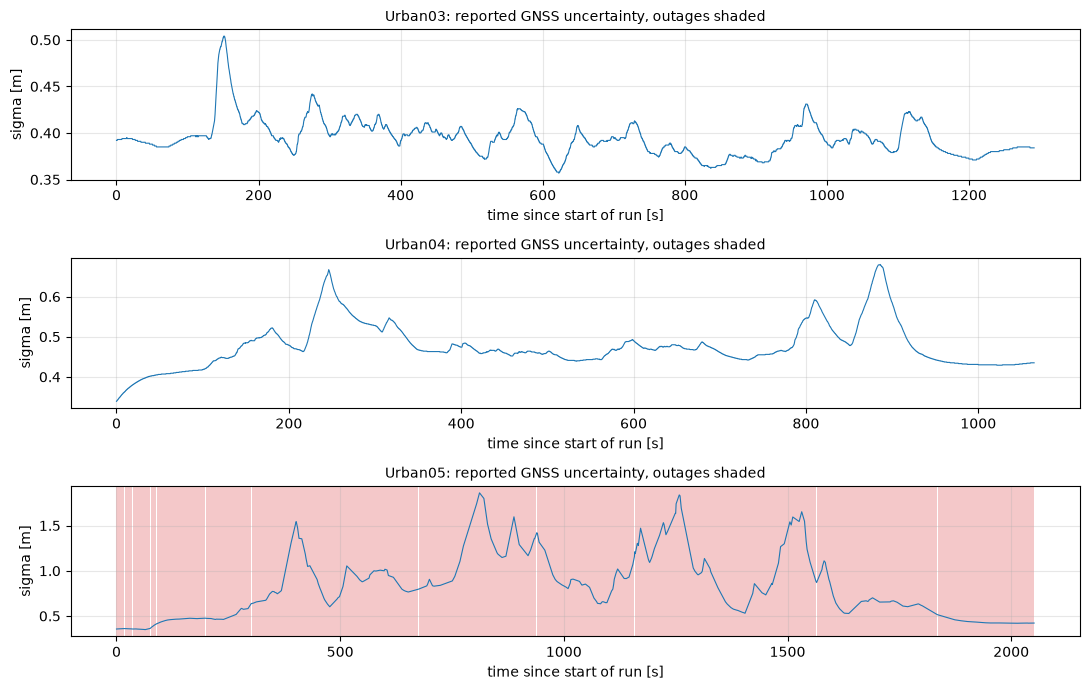

In [7]:
fig, axes = plt.subplots(len(quality), 1, figsize=(11, 7), sharex=False)

for ax, (name, df) in zip(axes, quality.items()):
    ax.plot(df["t"], df["sigma_e"], lw=0.8, label="reported 1-sigma east")

    # shade every interval longer than 1 s, i.e. every real outage
    for t_end, gap in zip(df["t"], df["gap"]):
        if gap is not None and gap > 1.0:
            ax.axvspan(t_end - gap, t_end, color="tab:red", alpha=0.25, lw=0)

    ax.set_title(f"{name}: reported GNSS uncertainty, outages shaded", fontsize=10)
    ax.set_ylabel("sigma [m]")
    ax.set_xlabel("time since start of run [s]")
    ax.grid(alpha=0.3)

fig.tight_layout()

## What this means for the experiments

Fill in after running the cells above. The questions the plot should settle:

- **Is the covariance usable?** If `cov_type` is 2 everywhere and the values are non-zero, $R$ can vary per measurement, which is branch 1 of §14's table. Note that it is still the receiver's own estimate and known to be optimistic, so it wants a tuning scale factor $s$ in the config rather than being trusted raw.
- **Which sequence carries E3?** E3 needs real GNSS loss. A sequence with no gaps at all cannot show it, however urban the street looked.
- **Which sequence carries the controlled experiments?** E1, E2, E4, E5 and E6 want a clean, continuous run with the best ground truth, so that synthetic outages are the only thing being varied.
- **Does the README still describe reality?** It currently says city driving degrades GNSS. Check that against what these three runs actually do.

---

### Next

1. Convert WGS84 to a local ENU frame with `pymap3d` and plot the GNSS track against the reference.
2. Compare the reported sigma against the **actual** error versus the reference. If the receiver claims 0.5 m while being off by several metres, that is the overconfidence story from `GNSS.md` section 5, measured on real data, and it belongs in the README.
3. Then write `src/data_loader.py`.